In [58]:
# Perform imports and load the dataset:
import pandas as pd
df = pd.read_csv("Processed_Reviews.csv",encoding="ISO-8859-1")
df.shape
df.head()
df.info()
# Checking for null values
df.isnull().sum()
# Checking Duplicate values
df.duplicated().sum()
# Drop Duplicate values
df=df.drop_duplicates()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Review                 13 non-null     object
 1   lowercased             13 non-null     object
 2   urls_removed           13 non-null     object
 3   html_removed           13 non-null     object
 4   emojis_removed         13 non-null     object
 5   slangs_replaced        13 non-null     object
 6   contractions_replaced  13 non-null     object
 7   punctuations_removed   13 non-null     object
 8   numbers_removed        13 non-null     object
 9   spelling_corrected     13 non-null     object
 10  stopwords_removed      13 non-null     object
 11  stemmed_words          13 non-null     object
 12  lemmatized             13 non-null     object
 13  tokenized              13 non-null     object
 14  label                  13 non-null     object
dtypes: object(15)
memory usag

(13, 15)

In [59]:
df.describe()
df.groupby('label').describe()

Review                                                            \
          count unique                                                top   
label                                                                       
negative      2      2  Wow!!! This product is awesome... but a bit ex...   
positive     11     11  The product arrived on time. Packaging was gre...   

              lowercased         \
         freq      count unique   
label                             
negative    1          2      2   
positive    1         11     11   

                                                                 urls_removed  \
                                                        top freq        count   
label                                                                           
negative  wow!!! this product is awesome... but a bit ex...    1            2   
positive  the product arrived on time. packaging was gre...    1           11   

                 ...                                 stemmed_words       \
         unique  ...                                           top freq   
label            ...                                                      
negative      2  ...                 wow product awesom bit expens    1   
positive     11  ...  product arriv time packag great qualiti amaz    1   

         lemmatized                                                            \
              count unique                                                top   
label                                                                           
negative          2      2                  wow product awesome bit expensive   
positive         11     11  product arrive time packaging great quality am...   

              tokenized         \
         freq     count unique   
label                            
negative    1         2      2   
positive    1        11     11   

                                                                  
                                                        top freq  
label                                                             
negative  ['wow', 'product', 'awesome', 'bit', 'expensive']    1  
positive  ['product', 'arrive', 'time', 'packaging', 'gr...    1  

[2 rows x 56 columns]

,label_num,review_len
count,2.0,2.000000
mean,0.0,59.500000
std,0.0,6.363961
min,0.0,55.000000
25%,0.0,57.250000
50%,0.0,59.500000
75%,0.0,61.750000
max,0.0,64.000000


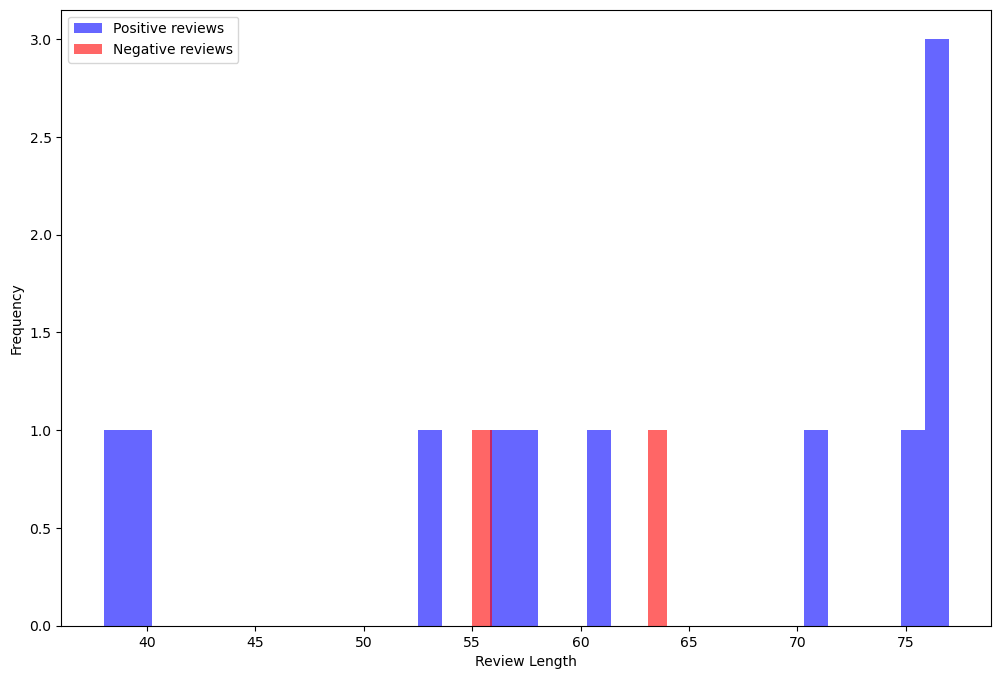

In [60]:
# convert label to a numerical variable
df['label_num'] = df.label.map({'negative':0, 'positive':1})
df.head()
df['review_len'] = df.Review.apply(len)
df.head()
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
df[df.label=='positive'].review_len.plot(bins=35, kind='hist', color='blue',
 label='Positive reviews', alpha=0.6)
df[df.label=='negative'].review_len.plot(kind='hist', color='red',
 label='Negative reviews', alpha=0.6)
plt.legend()
plt.xlabel("Review Length")
df[df.label=='positive'].describe()
df[df.label=='negative'].describe()

In [61]:
# import library
import re
import string
import nltk
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords
stemmer = nltk.SnowballStemmer("english")
def preprocess(text):
 text = text.lower() # Convert text to lowercase
 text = re.sub(r'\[.*?\]', '', text) # Remove text within square brackets
 text = re.sub(r'http\S+\s*\S+', '', text) # Remove URLs starting with http
 text = re.sub(r'www\.\S+', '', text) # Remove URLs starting with www
 text = re.sub(r'<.*?>', '', text) # Remove HTML tags
 text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
 text = re.sub(r'\b\w*\d\w*\b', '', text) # Remove words containing numbers
 text = ' '.join(word for word in text.split(' ') if word not in stop_words) #remove stopwords
 text = ' '.join(stemmer.stem(word) for word in text.split(' ')) #stemming
 return text
df['review_clean'] = df['Review'].apply(preprocess)
df.head(20)
print(df['review_clean'][5])
%pip install wordcloud

product amaz love
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


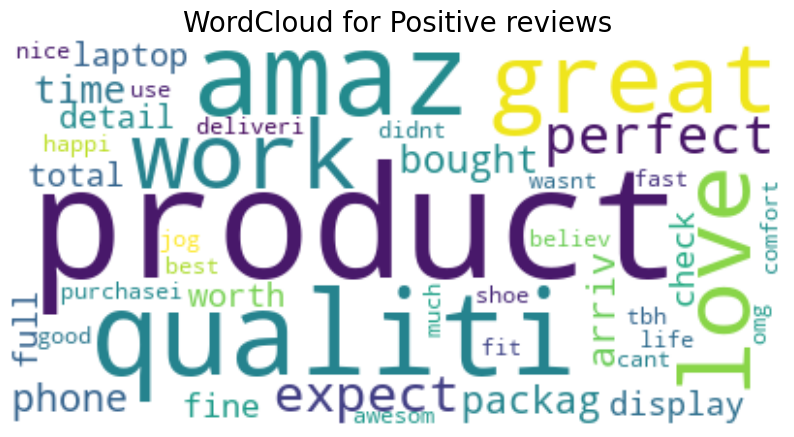

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
# Create a WordCloud object
wc = WordCloud(
 background_color='white',
max_words=200,
 contour_color='steelblue', # Add contour color
 contour_width=2, # Add contour width
)
# Generate the WordCloud using text data for HAM messages
positive_text = ' '.join(text for text in df.loc[df['label'] == 'positive', 'review_clean'])
wc.generate(positive_text)
# Visualize the WordCloud
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title('WordCloud for Positive reviews', fontsize=20)
plt.axis('off')
plt.show()

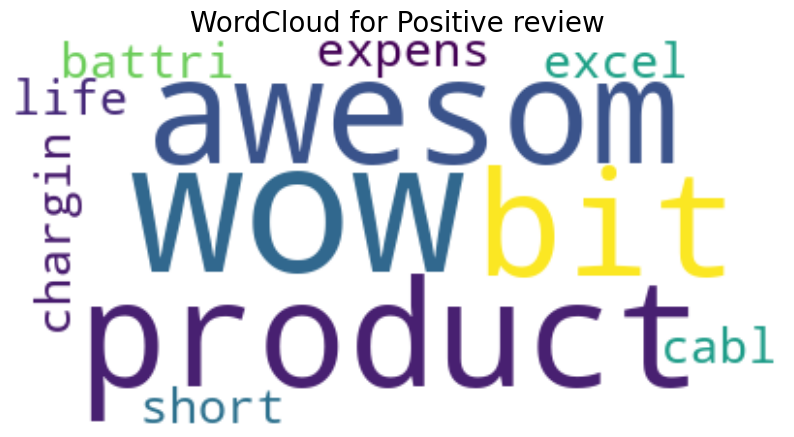

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
# Create a WordCloud object
wc = WordCloud(
 background_color='white',
 max_words=200,
 contour_color='steelblue', # Add contour color
 contour_width=2, # Add contour width
)
# Generate the WordCloud using text data for SPAM messages
positive_text = ' '.join(text for text in df.loc[df['label'] == 'negative', 'review_clean'])
wc.generate(positive_text)
# Visualize the WordCloud
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title('WordCloud for Negative review', fontsize=20)
plt.axis('off')
plt.show()

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vect = TfidfVectorizer()
X = tfidf_vect.fit_transform(df['review_clean'])
y = df['label']

In [65]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
# Split data into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
# Naive Bayes
nb_clf = MultinomialNB().fit(X_train, y_train)
# SVM
svm_clf = SVC(kernel='linear').fit(X_train, y_train)


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


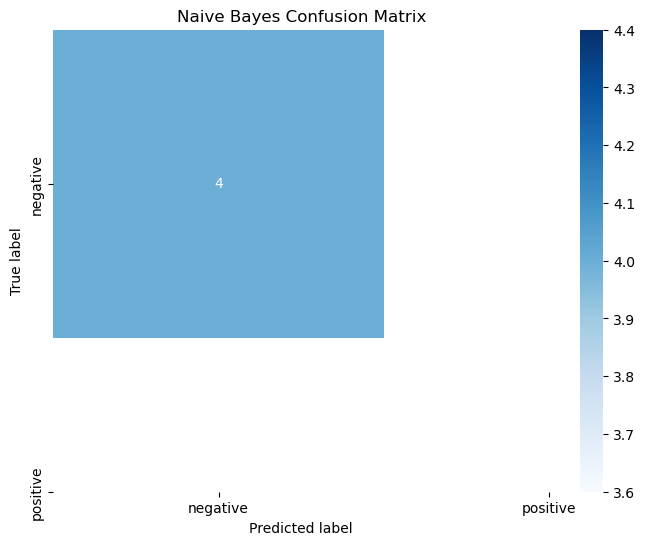

Naive Bayes Classifier Report:
              precision    recall  f1-score   support

    positive       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Naive Bayes Error Rate: 0.00


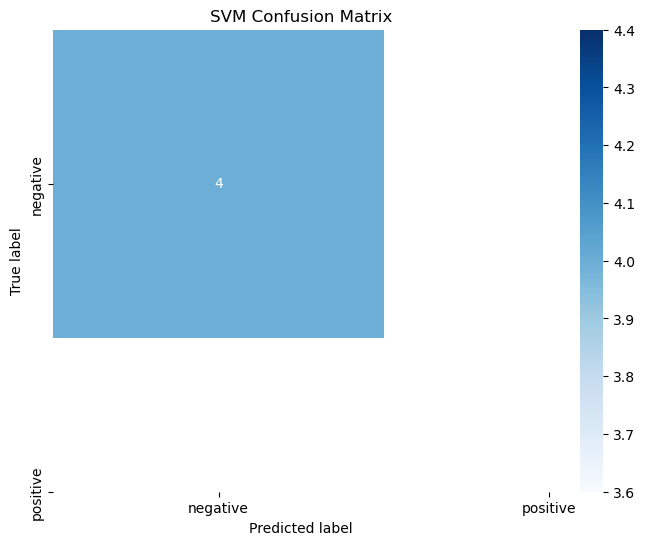


SVM Classifier Report:
              precision    recall  f1-score   support

    positive       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


SVM Error Rate: 0.00


In [66]:
# Performance metrics comparison
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score # Importing accuracy_score
# Naive Bayes
nb_predicted = nb_clf.predict(X_test)
nb_report = classification_report(y_test, nb_predicted)
# Calculate error rate for Naive Bayes
nb_error_rate = 1 - accuracy_score(y_test, nb_predicted)
nb_cm = confusion_matrix(y_test, nb_predicted)
# SVM
svm_predicted = svm_clf.predict(X_test)
svm_report = classification_report(y_test, svm_predicted)
# Calculate error rate for SVM
svm_error_rate = 1 - accuracy_score(y_test, svm_predicted)
svm_cm = confusion_matrix(y_test, svm_predicted)
nb_cm
import matplotlib.pyplot as plt
import seaborn as sns
# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
 plt.figure(figsize=(8, 6))
 sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
 plt.title(title)
 plt.xlabel('Predicted label')
 plt.ylabel('True label')
 plt.show()
# Plot confusion matrix for Naive Bayes
plot_confusion_matrix(nb_cm, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix')
print("Naive Bayes Classifier Report:")
print(nb_report)
print(f"\nNaive Bayes Error Rate: {nb_error_rate:.2f}")
# Plot confusion matrix for SVM
plot_confusion_matrix(svm_cm, classes=['negative', 'positive'], title='SVM Confusion Matrix')
print("\nSVM Classifier Report:")
print(svm_report)
print(f"\nSVM Error Rate: {svm_error_rate:.2f}")